In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from math import isclose
from scipy.optimize import fmin, minimize, root_scalar

%load_ext autoreload
%autoreload 2

In [2]:
from spin_package import utils, ising_fixed_e_1rsb

## 1RSB computation

In [24]:
p = 4
n_points_m = 100
n_points_T = 2
n_points_more_T = 2

x=0.99

T_kauz, T_dyn = utils.get_Tk_Td(p)

Teqs = np.hstack(
    (
        np.linspace(T_kauz, T_dyn, n_points_T),
        T_dyn + (T_dyn - T_kauz) / (n_points_T) * np.arange(1, n_points_more_T + 1),
    )
)
#Teqs = Teqs[27:]
es = -1 / (2 * Teqs)

In [25]:
T_dyn

0.678411054611206

In [26]:
Teqs = np.array([0.7, 0.8, 0.9])
es = - 1 / (2 * Teqs)

In [27]:
# file_path = f'./data/rs_p{p:d}.pkl'
# if os.path.exists(file_path):
#    print("Data is already saved.")
#
#    with open(file_path, 'rb') as f:
#        tmp = pickle.load(f)
#        data = tmp['data']
#        ms = tmp['ms']
#
#    print("Data is loaded.")
# else:
# print("Data is not saved.")

ms = np.linspace(0.0, 0.999, n_points_m)
data = utils.observables(["T", "q0", "q1", "m_check", "h", "e_check", "f", "s", "dAT"], (len(es), len(ms)))

q0_init = 0.99
q1_init = 1e-6
h_init = -0.1

for jdx, e in enumerate(tqdm(es, desc="1RSB")):
    for idx, m in enumerate(ms):
        beta = ising_fixed_e_1rsb.beta_q_e(q0_init, q1_init, m, e, p, h_init, x)
        h, q0, q1 = ising_fixed_e_1rsb.fixed_points_h_q(beta, m, e, p, x, q0_init=q0_init, q1_init=q1_init, h_init=h_init)

        data["q0"][jdx, idx] = q0
        data["q1"][jdx, idx] = q1
        data["h"][jdx, idx] = h
        data["T"][jdx, idx] = 1 / beta
        data["f"][jdx, idx] = ising_fixed_e_1rsb.compute_f_FP(beta, m , q0, q1, h, p, e, x)
        #data["s"][jdx, idx] = ising_fixed_e_1rsb.s_FP(m, q, h, p, e)
        data["dAT"][jdx, idx] = 1
        data["m_check"][jdx, idx] = ising_fixed_e_1rsb.compute_m_FP(beta, m , q0, q1, h, p, e, x)
        data["e_check"][jdx, idx] = ising_fixed_e_1rsb.compute_e_FP(beta, m , q0, q1, h, p, e, x)
        data["s"][jdx, idx] = (data["e_check"][jdx, idx] - data["f"][jdx, idx]) * beta


# with open(f'./data/rs_p{p:d}.pkl', 'wb') as f:
#    pickle.dump({'data': data, 'ms': ms}, f)
#
# print("Data is saved.")

1RSB:   0%|          | 0/3 [00:00<?, ?it/s]

In [28]:
data["m_check"]

array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

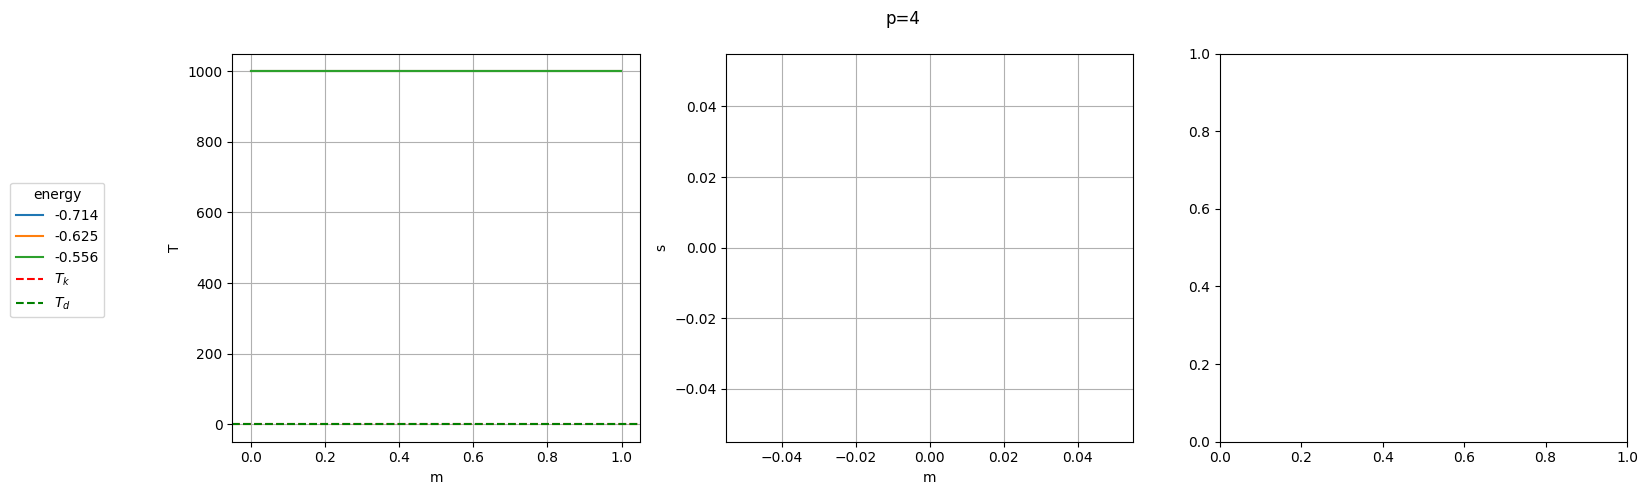

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"p={p}")

data_filtered = {
    key: value for key, value in data.items() if key in ["q", "T", "s"]
}

for jdx, e in enumerate(es):
    legend_name = utils.legend_name_Tk_Td_e(e, T_kauz, T_dyn)

    color = f"C{jdx:d}"
    stable_idxs = data["dAT"][jdx, :] > 0

    for idx, (key, item) in enumerate(data_filtered.items()):
        if key == 'q':
            axs[idx].plot(ms, item[jdx,:]-ms, '-', label=legend_name)
            axs[idx].set_ylabel("q-m")
        else:
            utils.plot_dashed_instable(axs[idx], ms, item[jdx], stable_idxs, color, legend_name)
            axs[idx].set_ylabel(key)
        axs[idx].set_xlabel("m")
        axs[idx].grid(True)

position_T = list(data_filtered.keys()).index("T")
axs[position_T].axhline(y=T_kauz, color="r", linestyle="--", label=r"$T_k$")
axs[position_T].axhline(y=T_dyn, color="g", linestyle="--", label=r"$T_d$")

handles, labels = [], []
ax = axs[position_T]
for handle, label in zip(*ax.get_legend_handles_labels()):
    if (handle, label) not in zip(handles, labels):
        handles.append(handle)
        labels.append(label)

lgd = fig.legend(handles, labels, loc="center left", bbox_to_anchor=(-0.1, 0.5), title="energy")

plt.tight_layout(rect=[0.1, 0, 1, 1])

plt.tight_layout()
# plt.savefig(
#     f"./imgs/FPpspin_p{p}_small.png",
#     bbox_extra_artists=(lgd,),
#     bbox_inches="tight",
#     dpi=360,
# )

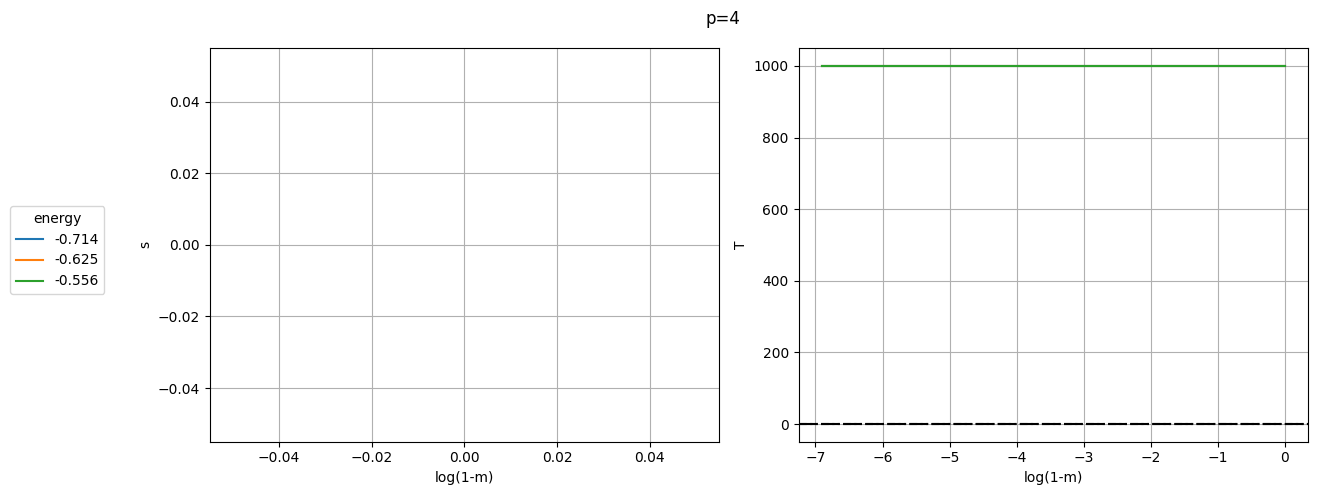

In [30]:
# plot s vs log(1-m) 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"p={p}")

for jdx, e in enumerate(es):
    legend_name = utils.legend_name_Tk_Td_e(e, T_kauz, T_dyn)

    color = f"C{jdx:d}"
    stable_idxs = data["dAT"][jdx, :] > 0

    utils.plot_dashed_instable(ax[0], np.log(1-ms), data["s"][jdx], stable_idxs, color, legend_name)
    utils.plot_dashed_instable(ax[1], np.log(1-ms), data["T"][jdx], stable_idxs, color, legend_name)
    #ax[0].plot(np.log(1-ms), data["s"][jdx], label=legend_name)
    #ax[1].plot(np.log(1-ms), data["T"][jdx], label=legend_name)

ax[0].set_ylabel("s")
ax[0].set_xlabel("log(1-m)")
ax[0].grid(True)

ax[1].set_ylabel("T")
ax[1].set_xlabel("log(1-m)")
ax[1].grid(True)
handles, labels = [], []
for handle, label in zip(*ax[1].get_legend_handles_labels()):
    if (handle, label) not in zip(handles, labels):
        handles.append(handle)
        labels.append(label)
position_T = list(data_filtered.keys()).index("T")
ax[1].axhline(y=T_kauz, color="k", linestyle="-.", label=r"$T_k$")
ax[1].axhline(y=T_dyn, color="k", linestyle="--", label=r"$T_d$")

lgd = fig.legend(handles, labels, loc="center left", bbox_to_anchor=(-0.1, 0.5), title="energy")

plt.tight_layout(rect=[0.1, 0, 1, 1])

plt.tight_layout()
plt.savefig(f'../imgs/1rsb/FPpspin_log1mm_p{p}.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi=360)
